In [30]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import sqlalchemy
from sklearn.model_selection import train_test_split 

In [32]:
# Conexão com o banco
SERVER = 'FELIPE-PC\\SQLEXPRESS'
DATABASE = 'DB_COPA_2026'
connection_url = f"mssql+pyodbc://@{SERVER}/{DATABASE}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = sqlalchemy.create_engine(connection_url)

print("Conexão bem sucedida!")

Conexão bem sucedida!


In [33]:
query = 'SELECT * FROM vw_abt_modelo_copa'
df_cru = pd.read_sql(query, engine)

print(f"Tabela carregada com sucesso! Dimensões: {df_cru.shape}")

Tabela carregada com sucesso! Dimensões: (11684, 12)


In [34]:
df_cru.sample(5)

,ID_PARTIDA,DATA_PARTIDA,ID_SELECAO_MANDANTE,ID_SELECAO_VISITANTE,PESO_COMPETICAO,DELTA_RANKING_PONTOS,MED_GOLS_MARCADOS_MANDANTE,MED_GOLS_MARCADOS_VISITANTE,HISTORICO_CONFRONTOS_TOTAIS,HISTORICO_VITORIAS_MANDANTE,HISTORICO_VITORIAS_VISITANTE,TARGET_RESULTADO
7900,37604,2014-03-05,272,147,2,243.00,1.200000,0.823529,13,12,0,2
10369,46206,2023-07-09,133,157,2,-231.56,1.259259,1.125000,15,3,10,0
8388,42261,2019-03-18,288,343,1,80.00,2.307692,2.875000,29,16,7,2
2152,46477,2023-10-12,80,327,2,1717.57,1.708333,2.388888,11,4,1,0
7846,48191,2025-03-24,267,253,2,0.00,0.500000,1.520000,3,0,3,0


In [35]:
# Filtro que irá tirar dados de 2024 para frente, pois não existe ranking de 2025 e 2026

df_filtrado = df_cru[(df_cru['DELTA_RANKING_PONTOS'] !=0 ) & (pd.to_datetime(df_cru['DATA_PARTIDA']).dt.year <= 2024)].copy()

print(f'Dados do df filtrado: {df_filtrado.shape}')

Dados do df filtrado: (10007, 12)


In [36]:
# Separar as variaveis do target p/ modelo

features = [
    'PESO_COMPETICAO', 
    'DELTA_RANKING_PONTOS', 
    'MED_GOLS_MARCADOS_MANDANTE', 
    'MED_GOLS_MARCADOS_VISITANTE',
    'HISTORICO_CONFRONTOS_TOTAIS', 
    'HISTORICO_VITORIAS_MANDANTE', 
    'HISTORICO_VITORIAS_VISITANTE'
]

X = df_filtrado[features]
y = df_filtrado['TARGET_RESULTADO']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Separação concluida com sucesso')
print(f'Base de treino tem: {X_train.shape} e a base de Teste tem: {X_test.shape}')

Separação concluida com sucesso
Base de treino tem: (8005, 7) e a base de Teste tem: (2002, 7)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import numpy as np 

In [39]:
# Scaler para normalizar (padronizar) os dados na mesma escala

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [40]:
# Instancia do modelo
# multinomial e lbfgs garantem que conseguimos prever as 3 variaveis, vitoria (visitante) empate ou vitoria(mandante)

modelo_copa = LogisticRegression(solver='lbfgs', max_iter = 500, random_state=42)

print('Modelo instanciado com sucesso!')


Modelo instanciado com sucesso!


In [41]:
# Usando kfold = 5
scores = cross_val_score(modelo_copa, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de cada kfold {np.round(scores * 100,2)}%')
print(f'Media de assertividade estabilizada: {round(scores.mean() * 100, 2)}%')
print('-' * 60)

Acurácia de cada kfold [56.59 54.72 56.46 55.72 55.9 ]%
Media de assertividade estabilizada: 55.88%
------------------------------------------------------------


In [42]:
# Treinar o modelo

modelo_copa.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

                       precision    recall  f1-score   support

Vitória Visitante (0)       0.52      0.50      0.51       577
           Empate (1)       0.52      0.03      0.05       471
 Vitória Mandante (2)       0.57      0.85      0.68       954

             accuracy                           0.55      2002
            macro avg       0.54      0.46      0.41      2002
         weighted avg       0.54      0.55      0.48      2002

------------------------------------------------------------


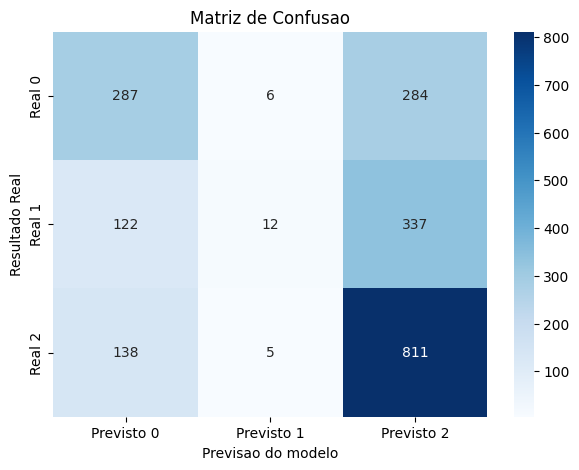

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fazer a previsão nos dados de teste
y_pred = modelo_copa.predict(X_test_scaled)

# Relatório de classificação

print(classification_report(y_test, y_pred, target_names=['Vitória Visitante (0)', 'Empate (1)', 'Vitória Mandante (2)']))
print('-' * 60)

# Matriz de confusao

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=['Previsto 0', 'Previsto 1', 'Previsto 2'], yticklabels=['Real 0', 'Real 1', 'Real 2'])

plt.title('Matriz de Confusao')
plt.ylabel('Resultado Real')
plt.xlabel('Previsao do modelo')
plt.show()

In [44]:
import joblib

# 1. Salva o modelo treinado e o padronizador de escala em arquivos físicos
joblib.dump(modelo_copa, 'modelo_copa_2026.pkl')
joblib.dump(scaler, 'scaler_copa_2026.pkl')

print("💾 Arquivos 'modelo_copa_2026.pkl' e 'scaler_copa_2026.pkl' salvos com sucesso!")
print("🎉 Sprint 3 concluída com louvor. O cérebro preditor está pronto para o deploy!")

💾 Arquivos 'modelo_copa_2026.pkl' e 'scaler_copa_2026.pkl' salvos com sucesso!
🎉 Sprint 3 concluída com louvor. O cérebro preditor está pronto para o deploy!
